In [22]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/pankrzysiu/cifar10-python/cifar-10-python.tar.gz
/kaggle/input/datasets/pankrzysiu/cifar10-python/cifar-10-batches-py/data_batch_1
/kaggle/input/datasets/pankrzysiu/cifar10-python/cifar-10-batches-py/data_batch_2
/kaggle/input/datasets/pankrzysiu/cifar10-python/cifar-10-batches-py/batches.meta
/kaggle/input/datasets/pankrzysiu/cifar10-python/cifar-10-batches-py/test_batch
/kaggle/input/datasets/pankrzysiu/cifar10-python/cifar-10-batches-py/data_batch_3
/kaggle/input/datasets/pankrzysiu/cifar10-python/cifar-10-batches-py/data_batch_5
/kaggle/input/datasets/pankrzysiu/cifar10-python/cifar-10-batches-py/data_batch_4
/kaggle/input/datasets/pankrzysiu/cifar10-python/cifar-10-batches-py/readme.html


# GoogLeNet / Inception Architecture Study

## Objective

The goal of this experiment is to study how the architectural design of GoogLeNet/Inception affects image-classification performance.

The focus is not simply to obtain the highest accuracy. Instead, the experiment is designed to understand how different architectural choices affect:

- Model capacity
- Training performance
- Validation performance
- Generalization to unseen data
- Overfitting

The study will use three controlled experiments:

1. Depth
2. Width
3. Branch Structure

Each experiment changes one major architectural factor while keeping the other important conditions fixed.

---

## Dataset

The experiments will use the CIFAR-10 dataset.

- Training samples: 50,000
- Test samples: 10,000
- Number of classes: 10
- Image size: 32 × 32
- Image channels: 3 (RGB)

The original training set will be divided into:

- Training set: 80%
- Validation set: 20%

The official CIFAR-10 test set will remain untouched until final evaluation.

---

## Data Preprocessing

The same preprocessing pipeline will be used for all GoogLeNet experiments.

### Training Transformations

- Random horizontal flip
- Normalization

### Evaluation Transformations

- Normalization only

CIFAR-10 normalization values:

```text
Mean = [0.4914, 0.4822, 0.4465]
Std  = [0.2470, 0.2435, 0.2616]

# Experiment 1 — Effect of Depth

## Objective

The purpose of this experiment is to investigate how increasing the number of Inception blocks affects the performance of a GoogLeNet-style CNN.

The main architectural variable is **depth**.

We will compare models with different numbers of Inception blocks while keeping the **width and branch structure fixed**.

---

## Experimental Design

Three models will be compared:

| Model | Number of Inception Blocks | Output Channels per Block |
|---|---:|---:|
| GoogLeNet2 | 2 | 64 |
| GoogLeNet3 | 3 | 64 |
| GoogLeNet4 | 4 | 64 |

Each Inception block will use the same four-branch structure.

### Inception Block

1. **1 × 1 convolution** → 16 channels
2. **1 × 1 convolution → 3 × 3 convolution** → 32 channels
3. **1 × 1 convolution → 5 × 5 convolution** → 8 channels
4. **3 × 3 max pooling → 1 × 1 convolution** → 8 channels

The outputs of the four branches are concatenated along the channel dimension:

```text
16 + 32 + 8 + 8 = 64 channels

In [23]:
!git clone https://github.com/davidmba819/cnn-architecture-study.git

Cloning into 'cnn-architecture-study'...
remote: Enumerating objects: 41, done.
remote: Counting objects: 100% (41/41), done.
remote: Compressing objects: 100% (28/28), done.
remote: Total 41 (delta 15), reused 28 (delta 8), pack-reused 0 (from 0)
Receiving objects: 100% (41/41), 1.96 MiB | 20.26 MiB/s, done.
Resolving deltas: 100% (15/15), done.


In [24]:
%cd /kaggle/working/cnn-architecture-study

/kaggle/working/cnn-architecture-study


In [25]:
import sys

sys.path.append("/kaggle/working/cnn-architecture-study")

import cnn_utils

In [26]:
import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets

In [27]:
!find /kaggle/input -maxdepth 4 -print | head -100

/kaggle/input
/kaggle/input/datasets
/kaggle/input/datasets/pankrzysiu
/kaggle/input/datasets/pankrzysiu/cifar10-python
/kaggle/input/datasets/pankrzysiu/cifar10-python/cifar-10-python.tar.gz
/kaggle/input/datasets/pankrzysiu/cifar10-python/cifar-10-batches-py


In [28]:
!find /kaggle/input -type d -print

/kaggle/input
/kaggle/input/datasets
/kaggle/input/datasets/pankrzysiu
/kaggle/input/datasets/pankrzysiu/cifar10-python
/kaggle/input/datasets/pankrzysiu/cifar10-python/cifar-10-batches-py


In [29]:

DATA_DIR = "/kaggle/input/datasets/pankrzysiu/cifar10-python"


In [30]:
from torchvision import datasets

train_dataset = datasets.CIFAR10(
    root=DATA_DIR,
    train=True,
    download=False,
    transform=None
)

test_dataset = datasets.CIFAR10(
    root=DATA_DIR,
    train=False,
    download=False,
    transform=None
)

In [31]:
print(f"Training samples: {len(train_dataset)}")
print(f"Test samples: {len(test_dataset)}")

Training samples: 50000
Test samples: 10000


In [32]:
train_transform, eval_transform = cnn_utils.create_transforms()

In [33]:
print(train_transform)
print(eval_transform)

Compose(
    RandomHorizontalFlip(p=0.5)
    ToTensor()
    Normalize(mean=[0.4914, 0.4822, 0.4465], std=[0.247, 0.2435, 0.2616])
)
Compose(
    ToTensor()
    Normalize(mean=[0.4914, 0.4822, 0.4465], std=[0.247, 0.2435, 0.2616])
)


In [34]:
train_data, val_data = cnn_utils.prepare_datasets(
    train_dataset,
    val_ratio=0.2,
    seed=42
)

In [35]:
train_loader, val_loader, test_loader = cnn_utils.create_dataloaders(
    train_data=train_data,
    val_data=val_data,
    test_data=test_dataset,
    train_transform=train_transform,
    eval_transform=eval_transform,
    batch_size=64,
    num_workers=2
)

In [36]:
images, labels = next(iter(train_loader))

print(f"Images shape: {images.shape}")
print(f"Labels shape: {labels.shape}")

Images shape: torch.Size([64, 3, 32, 32])
Labels shape: torch.Size([64])


In [37]:
class InceptionBlock(nn.Module):

    def __init__(
        self,
        in_channels,
        c1,
        r3,
        c3,
        r5,
        c5,
        pool_proj
    ):
        super().__init__()

        # Branch 1: 1×1 convolution
        self.branch1 = nn.Sequential(
            nn.Conv2d(
                in_channels,
                c1,
                kernel_size=1
            ),
            nn.ReLU()
        )

        # Branch 2: 1×1 → 3×3
        self.branch2 = nn.Sequential(
            nn.Conv2d(
                in_channels,
                r3,
                kernel_size=1
            ),
            nn.ReLU(),

            nn.Conv2d(
                r3,
                c3,
                kernel_size=3,
                padding=1
            ),
            nn.ReLU()
        )

        # Branch 3: 1×1 → 5×5
        self.branch3 = nn.Sequential(
            nn.Conv2d(
                in_channels,
                r5,
                kernel_size=1
            ),
            nn.ReLU(),

            nn.Conv2d(
                r5,
                c5,
                kernel_size=5,
                padding=2
            ),
            nn.ReLU()
        )

        # Branch 4: MaxPool → 1×1
        self.branch4 = nn.Sequential(
            nn.MaxPool2d(
                kernel_size=3,
                stride=1,
                padding=1
            ),

            nn.Conv2d(
                in_channels,
                pool_proj,
                kernel_size=1
            ),
            nn.ReLU()
        )

        self._initialize_weights()

    def _initialize_weights(self):

        for layer in self.modules():

            if isinstance(layer, nn.Conv2d):

                nn.init.kaiming_normal_(
                    layer.weight,
                    mode="fan_out",
                    nonlinearity="relu"
                )

                if layer.bias is not None:
                    nn.init.zeros_(layer.bias)

    def forward(self, x):

        branch1 = self.branch1(x)
        branch2 = self.branch2(x)
        branch3 = self.branch3(x)
        branch4 = self.branch4(x)

        return torch.cat(
            [branch1, branch2, branch3, branch4],
            dim=1
        )

In [38]:
inception_block = InceptionBlock(
    in_channels=3,
    c1=16,
    r3=16,
    c3=32,
    r5=8,
    c5=8,
    pool_proj=8
)

In [39]:
images, labels = next(iter(train_loader))

output = inception_block(images)

print(f"Input shape:  {images.shape}")
print(f"Output shape: {output.shape}")

Input shape:  torch.Size([64, 3, 32, 32])
Output shape: torch.Size([64, 64, 32, 32])


In [40]:
class GoogLeNet(nn.Module):

    def __init__(self, num_blocks=3):
        super().__init__()

        blocks = []
        in_channels = 3

        for _ in range(num_blocks):

            blocks.append(
                InceptionBlock(
                    in_channels=in_channels,
                    c1=16,
                    r3=16,
                    c3=32,
                    r5=8,
                    c5=8,
                    pool_proj=8
                )
            )

            in_channels = 64

        self.blocks = nn.ModuleList(blocks)

        self.pool = nn.MaxPool2d(
            kernel_size=2,
            stride=2
        )

        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d((1, 1)),
            nn.Flatten(),
            nn.Linear(64, 10)
        )

        self._initialize_classifier()

    def _initialize_classifier(self):

        linear_layer = self.classifier[2]

        nn.init.xavier_normal_(linear_layer.weight)
        nn.init.zeros_(linear_layer.bias)

    def forward(self, x):

        for i, block in enumerate(self.blocks):

            x = block(x)

            if i < len(self.blocks) - 1:
                x = self.pool(x)

        x = self.classifier(x)

        return x

In [41]:
model = GoogLeNet(num_blocks=3)
print(model)

GoogLeNet(
  (blocks): ModuleList(
    (0): InceptionBlock(
      (branch1): Sequential(
        (0): Conv2d(3, 16, kernel_size=(1, 1), stride=(1, 1))
        (1): ReLU()
      )
      (branch2): Sequential(
        (0): Conv2d(3, 16, kernel_size=(1, 1), stride=(1, 1))
        (1): ReLU()
        (2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (3): ReLU()
      )
      (branch3): Sequential(
        (0): Conv2d(3, 8, kernel_size=(1, 1), stride=(1, 1))
        (1): ReLU()
        (2): Conv2d(8, 8, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
        (3): ReLU()
      )
      (branch4): Sequential(
        (0): MaxPool2d(kernel_size=3, stride=1, padding=1, dilation=1, ceil_mode=False)
        (1): Conv2d(3, 8, kernel_size=(1, 1), stride=(1, 1))
        (2): ReLU()
      )
    )
    (1-2): 2 x InceptionBlock(
      (branch1): Sequential(
        (0): Conv2d(64, 16, kernel_size=(1, 1), stride=(1, 1))
        (1): ReLU()
      )
      (branch2): Sequenti

In [42]:
images, labels = next(iter(train_loader))

output = model(images)

print(f"Input shape:  {images.shape}")
print(f"Output shape: {output.shape}")

Input shape:  torch.Size([64, 3, 32, 32])
Output shape: torch.Size([64, 10])


# Experiment 1 — Depth

## Sub-experiment 1 — GoogLeNet2

### Objective

The first model in the depth experiment uses **two Inception blocks**.

The purpose is to establish the performance of a relatively shallow GoogLeNet architecture before increasing the number of Inception blocks in the next experiments.

### Architecture

The model consists of:

```text
Input
3 × 32 × 32
      ↓
Inception Block 1
64 × 32 × 32
      ↓
MaxPool
64 × 16 × 16
      ↓
Inception Block 2
64 × 16 × 16
      ↓
Adaptive Average Pooling
64 × 1 × 1
      ↓
Linear Layer
10 classes

In [43]:
model = GoogLeNet(num_blocks=2)

print(model)

GoogLeNet(
  (blocks): ModuleList(
    (0): InceptionBlock(
      (branch1): Sequential(
        (0): Conv2d(3, 16, kernel_size=(1, 1), stride=(1, 1))
        (1): ReLU()
      )
      (branch2): Sequential(
        (0): Conv2d(3, 16, kernel_size=(1, 1), stride=(1, 1))
        (1): ReLU()
        (2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (3): ReLU()
      )
      (branch3): Sequential(
        (0): Conv2d(3, 8, kernel_size=(1, 1), stride=(1, 1))
        (1): ReLU()
        (2): Conv2d(8, 8, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
        (3): ReLU()
      )
      (branch4): Sequential(
        (0): MaxPool2d(kernel_size=3, stride=1, padding=1, dilation=1, ceil_mode=False)
        (1): Conv2d(3, 8, kernel_size=(1, 1), stride=(1, 1))
        (2): ReLU()
      )
    )
    (1): InceptionBlock(
      (branch1): Sequential(
        (0): Conv2d(64, 16, kernel_size=(1, 1), stride=(1, 1))
        (1): ReLU()
      )
      (branch2): Sequential(
  

In [45]:
loss_function = nn.CrossEntropyLoss()
optimizer = optim.SGD(
    model.parameters(),
    lr=0.01,
    momentum=0.9
)

In [47]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print(f"Using device: {device}")

Using device: cuda


In [48]:
model, history_googlenet2 = cnn_utils.train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    loss_function=loss_function,
    optimizer=optimizer,
    device=device,
    epochs=20
)

Epoch [1/20] Train Loss: 1.8744 | Train Acc: 0.2995 | Val Loss: 1.7013 | Val Acc: 0.3734
Epoch [2/20] Train Loss: 1.6247 | Train Acc: 0.3966 | Val Loss: 1.5290 | Val Acc: 0.4398
Epoch [3/20] Train Loss: 1.5339 | Train Acc: 0.4387 | Val Loss: 1.4789 | Val Acc: 0.4743
Epoch [4/20] Train Loss: 1.4511 | Train Acc: 0.4743 | Val Loss: 1.3984 | Val Acc: 0.5018
Epoch [5/20] Train Loss: 1.3983 | Train Acc: 0.4942 | Val Loss: 1.3706 | Val Acc: 0.5173
Epoch [6/20] Train Loss: 1.3430 | Train Acc: 0.5199 | Val Loss: 1.2892 | Val Acc: 0.5386
Epoch [7/20] Train Loss: 1.3063 | Train Acc: 0.5319 | Val Loss: 1.3520 | Val Acc: 0.5160
Epoch [8/20] Train Loss: 1.2552 | Train Acc: 0.5520 | Val Loss: 1.2747 | Val Acc: 0.5450
Epoch [9/20] Train Loss: 1.2227 | Train Acc: 0.5656 | Val Loss: 1.2038 | Val Acc: 0.5702
Epoch [10/20] Train Loss: 1.2012 | Train Acc: 0.5704 | Val Loss: 1.1841 | Val Acc: 0.5802
Epoch [11/20] Train Loss: 1.1752 | Train Acc: 0.5844 | Val Loss: 1.2049 | Val Acc: 0.5688
Epoch [12/20] Train

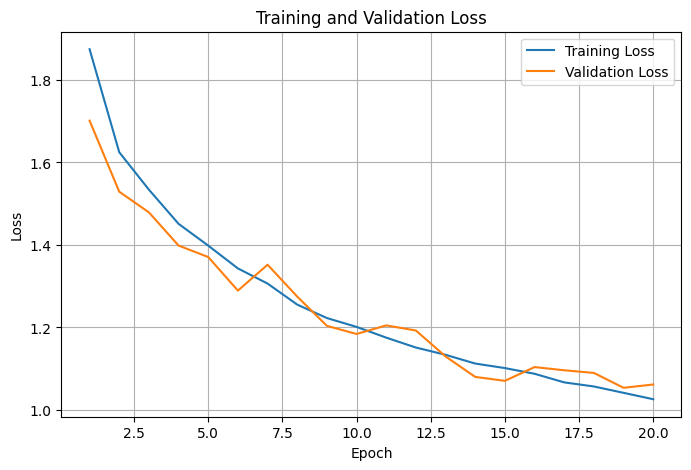

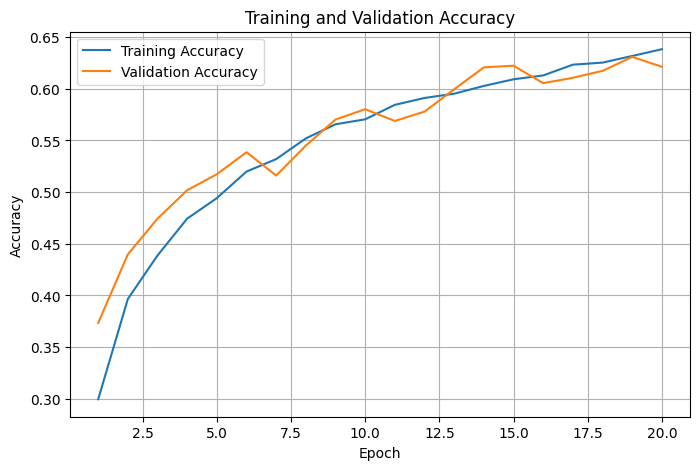

In [49]:
cnn_utils.plot_history(history_googlenet2)

In [50]:
test_loss, test_accuracy = cnn_utils.test_model(
    model=model,
    test_loader=test_loader,
    loss_function=loss_function,
    device=device
)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.2f}%")

Test Loss: 1.0676
Test Accuracy: 0.6153
Test Loss: 1.0676
Test Accuracy: 0.62%


## Sub-experiment 1 — GoogLeNet2 Results

The GoogLeNet2 model was trained for 20 epochs using the fixed training configuration for the depth experiment.

### Results

| Metric | Result |
|---|---:|
| Number of Inception Blocks | 2 |
| Output Channels per Block | 64 |
| Final Training Loss | 1.0259 |
| Final Training Accuracy | 63.82% |
| Final Validation Loss | 1.0616 |
| Final Validation Accuracy | 62.13% |
| Test Loss | 1.0676 |
| Test Accuracy | 61.53% |

### Training Behavior

The training loss decreased steadily throughout the 20 epochs, while the training accuracy increased from 29.95% to 63.82%.

Validation loss also decreased overall, and validation accuracy increased from 37.34% to 62.13%.

The training and validation curves remained relatively close throughout training, with no large separation between them by the end of the experiment.

### Observation

The 2-block model achieved a test accuracy of **61.53%** after 20 epochs.

This result provides the first reference point for the depth experiment.

The model will be compared with deeper versions using the same training conditions:

- GoogLeNet2 — 2 Inception blocks
- GoogLeNet3 — 3 Inception blocks
- GoogLeNet4 — 4 Inception blocks

The purpose of the comparison is to determine how increasing the number of Inception blocks affects model performance and generalization.

## Sub-experiment 2 — GoogLeNet3

### Objective

The second model in the depth experiment uses **three Inception blocks**.

The purpose of this experiment is to determine how adding one additional Inception block affects the model compared with the 2-block GoogLeNet model.

The width and branch structure remain unchanged so that the main architectural variable is **depth**.

### Architecture

The model consists of:

```text
Input
3 × 32 × 32
      ↓
Inception Block 1
64 × 32 × 32
      ↓
MaxPool
64 × 16 × 16
      ↓
Inception Block 2
64 × 16 × 16
      ↓
MaxPool
64 × 8 × 8
      ↓
Inception Block 3
64 × 8 × 8
      ↓
Adaptive Average Pooling
64 × 1 × 1
      ↓
Linear Layer
10 classes

In [51]:
model = GoogLeNet(num_blocks=3)

print(model)

GoogLeNet(
  (blocks): ModuleList(
    (0): InceptionBlock(
      (branch1): Sequential(
        (0): Conv2d(3, 16, kernel_size=(1, 1), stride=(1, 1))
        (1): ReLU()
      )
      (branch2): Sequential(
        (0): Conv2d(3, 16, kernel_size=(1, 1), stride=(1, 1))
        (1): ReLU()
        (2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (3): ReLU()
      )
      (branch3): Sequential(
        (0): Conv2d(3, 8, kernel_size=(1, 1), stride=(1, 1))
        (1): ReLU()
        (2): Conv2d(8, 8, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
        (3): ReLU()
      )
      (branch4): Sequential(
        (0): MaxPool2d(kernel_size=3, stride=1, padding=1, dilation=1, ceil_mode=False)
        (1): Conv2d(3, 8, kernel_size=(1, 1), stride=(1, 1))
        (2): ReLU()
      )
    )
    (1-2): 2 x InceptionBlock(
      (branch1): Sequential(
        (0): Conv2d(64, 16, kernel_size=(1, 1), stride=(1, 1))
        (1): ReLU()
      )
      (branch2): Sequenti

In [52]:
loss_function = nn.CrossEntropyLoss()
optimizer = optim.SGD(
    model.parameters(),
    lr=0.01,
    momentum=0.9
)

In [53]:
model, history_googlenet2 = cnn_utils.train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    loss_function=loss_function,
    optimizer=optimizer,
    device=device,
    epochs=20
)

Epoch [1/20] Train Loss: 1.7817 | Train Acc: 0.3425 | Val Loss: 1.5290 | Val Acc: 0.4392
Epoch [2/20] Train Loss: 1.5059 | Train Acc: 0.4482 | Val Loss: 1.4279 | Val Acc: 0.4640
Epoch [3/20] Train Loss: 1.3807 | Train Acc: 0.4980 | Val Loss: 1.3443 | Val Acc: 0.5065
Epoch [4/20] Train Loss: 1.2814 | Train Acc: 0.5379 | Val Loss: 1.2127 | Val Acc: 0.5647
Epoch [5/20] Train Loss: 1.2015 | Train Acc: 0.5681 | Val Loss: 1.1561 | Val Acc: 0.5864
Epoch [6/20] Train Loss: 1.1420 | Train Acc: 0.5915 | Val Loss: 1.0763 | Val Acc: 0.6161
Epoch [7/20] Train Loss: 1.0907 | Train Acc: 0.6121 | Val Loss: 1.0309 | Val Acc: 0.6298
Epoch [8/20] Train Loss: 1.0489 | Train Acc: 0.6237 | Val Loss: 1.1087 | Val Acc: 0.6015
Epoch [9/20] Train Loss: 1.0083 | Train Acc: 0.6412 | Val Loss: 1.1082 | Val Acc: 0.6080
Epoch [10/20] Train Loss: 0.9804 | Train Acc: 0.6498 | Val Loss: 1.0236 | Val Acc: 0.6342
Epoch [11/20] Train Loss: 0.9609 | Train Acc: 0.6577 | Val Loss: 1.0467 | Val Acc: 0.6379
Epoch [12/20] Train

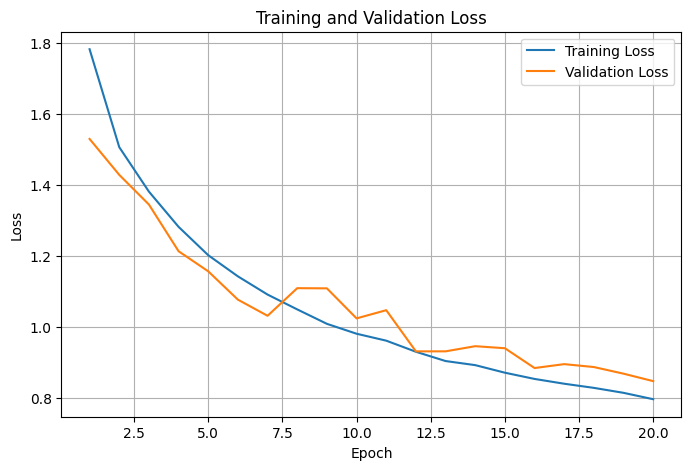

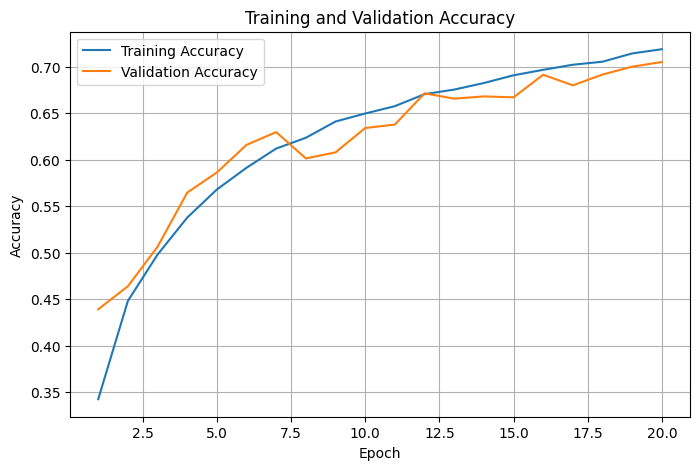

In [54]:
cnn_utils.plot_history(history_googlenet2)

In [55]:
test_loss, test_accuracy = cnn_utils.test_model(
    model=model,
    test_loader=test_loader,
    loss_function=loss_function,
    device=device
)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.2f}%")

Test Loss: 0.8611
Test Accuracy: 0.6928
Test Loss: 0.8611
Test Accuracy: 0.69%


## Sub-experiment 2 — GoogLeNet3 Results

The GoogLeNet3 model was trained for 20 epochs using the fixed training configuration for the depth experiment.

### Results

| Metric | Result |
|---|---:|
| Number of Inception Blocks | 3 |
| Output Channels per Block | 64 |
| Final Training Loss | 0.7959 |
| Final Training Accuracy | 71.89% |
| Final Validation Loss | 0.8468 |
| Final Validation Accuracy | 70.52% |
| Test Loss | 0.8611 |
| Test Accuracy | 69.28% |

### Training Behavior

The training loss decreased from 1.7817 at the beginning of training to 0.7959 by epoch 20.

Training accuracy increased from 34.25% to 71.89%, while validation accuracy increased from 43.92% to 70.52%.

The training and validation curves followed a similar pattern throughout most of the training process. By the end of training, the training accuracy was slightly higher than the validation accuracy.

### Observation

The 3-block model achieved a test accuracy of **69.28%** after 20 epochs.

The 3-block model will be compared with the 2-block model to examine the effect of increasing depth:

| Model | Inception Blocks | Test Accuracy |
|---|---:|---:|
| GoogLeNet2 | 2 | 61.53% |
| GoogLeNet3 | 3 | 69.28% |

The final comparison will be completed after training the 4-block model under the same experimental conditions.

## Sub-experiment 3 — GoogLeNet4

### Objective

The third model in the depth experiment uses **four Inception blocks**.

The purpose is to investigate whether increasing the depth from three to four Inception blocks produces further improvements in training, validation, and test performance.

The width and branch structure remain unchanged so that **depth remains the main architectural variable**.

### Architecture

The model consists of:

```text
Input
3 × 32 × 32
      ↓
Inception Block 1
64 × 32 × 32
      ↓
MaxPool
64 × 16 × 16
      ↓
Inception Block 2
64 × 16 × 16
      ↓
MaxPool
64 × 8 × 8
      ↓
Inception Block 3
64 × 8 × 8
      ↓
MaxPool
64 × 4 × 4
      ↓
Inception Block 4
64 × 4 × 4
      ↓
Adaptive Average Pooling
64 × 1 × 1
      ↓
Linear Layer
10 classes

In [56]:
model = GoogLeNet(num_blocks=4)

print(model)

GoogLeNet(
  (blocks): ModuleList(
    (0): InceptionBlock(
      (branch1): Sequential(
        (0): Conv2d(3, 16, kernel_size=(1, 1), stride=(1, 1))
        (1): ReLU()
      )
      (branch2): Sequential(
        (0): Conv2d(3, 16, kernel_size=(1, 1), stride=(1, 1))
        (1): ReLU()
        (2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (3): ReLU()
      )
      (branch3): Sequential(
        (0): Conv2d(3, 8, kernel_size=(1, 1), stride=(1, 1))
        (1): ReLU()
        (2): Conv2d(8, 8, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
        (3): ReLU()
      )
      (branch4): Sequential(
        (0): MaxPool2d(kernel_size=3, stride=1, padding=1, dilation=1, ceil_mode=False)
        (1): Conv2d(3, 8, kernel_size=(1, 1), stride=(1, 1))
        (2): ReLU()
      )
    )
    (1-3): 3 x InceptionBlock(
      (branch1): Sequential(
        (0): Conv2d(64, 16, kernel_size=(1, 1), stride=(1, 1))
        (1): ReLU()
      )
      (branch2): Sequenti

In [57]:
loss_function = nn.CrossEntropyLoss()
optimizer = optim.SGD(
    model.parameters(),
    lr=0.01,
    momentum=0.9
)

In [58]:
model, history_googlenet4 = cnn_utils.train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    loss_function=loss_function,
    optimizer=optimizer,
    device=device,
    epochs=20
)

Epoch [1/20] Train Loss: 1.8358 | Train Acc: 0.3201 | Val Loss: 1.6648 | Val Acc: 0.3959
Epoch [2/20] Train Loss: 1.5086 | Train Acc: 0.4412 | Val Loss: 1.4364 | Val Acc: 0.4658
Epoch [3/20] Train Loss: 1.3857 | Train Acc: 0.4943 | Val Loss: 1.3339 | Val Acc: 0.5144
Epoch [4/20] Train Loss: 1.3090 | Train Acc: 0.5211 | Val Loss: 1.2381 | Val Acc: 0.5516
Epoch [5/20] Train Loss: 1.2279 | Train Acc: 0.5540 | Val Loss: 1.2285 | Val Acc: 0.5504
Epoch [6/20] Train Loss: 1.1662 | Train Acc: 0.5769 | Val Loss: 1.1526 | Val Acc: 0.5782
Epoch [7/20] Train Loss: 1.1074 | Train Acc: 0.6007 | Val Loss: 1.1463 | Val Acc: 0.5960
Epoch [8/20] Train Loss: 1.0752 | Train Acc: 0.6151 | Val Loss: 1.0671 | Val Acc: 0.6171
Epoch [9/20] Train Loss: 1.0315 | Train Acc: 0.6307 | Val Loss: 1.0468 | Val Acc: 0.6254
Epoch [10/20] Train Loss: 0.9945 | Train Acc: 0.6472 | Val Loss: 0.9792 | Val Acc: 0.6494
Epoch [11/20] Train Loss: 0.9675 | Train Acc: 0.6563 | Val Loss: 0.9817 | Val Acc: 0.6417
Epoch [12/20] Train

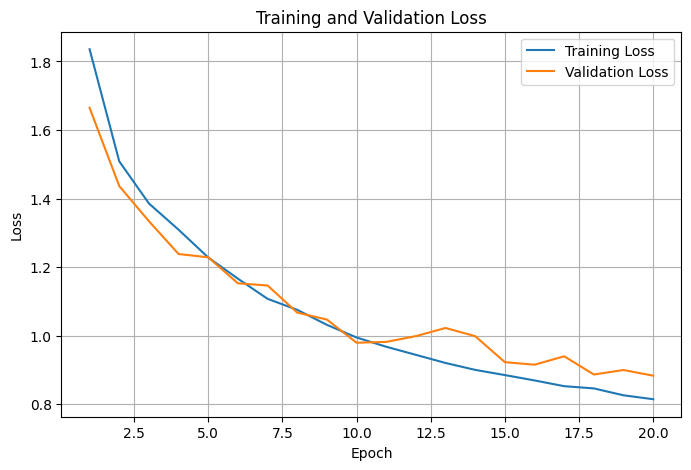

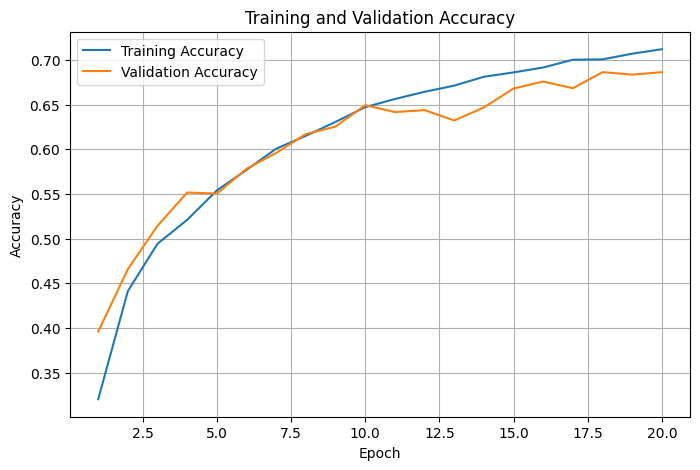

In [59]:
cnn_utils.plot_history(history_googlenet4)

In [60]:
test_loss, test_accuracy = cnn_utils.test_model(
    model=model,
    test_loader=test_loader,
    loss_function=loss_function,
    device=device
)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.2f}%")

Test Loss: 0.8991
Test Accuracy: 0.6848
Test Loss: 0.8991
Test Accuracy: 0.68%


## Sub-experiment 3 — GoogLeNet4 Results

The GoogLeNet4 model was trained for 20 epochs using the fixed training configuration for the depth experiment.

### Results

| Metric | Result |
|---|---:|
| Number of Inception Blocks | 4 |
| Output Channels per Block | 64 |
| Final Training Loss | 0.8144 |
| Final Training Accuracy | 71.21% |
| Final Validation Loss | 0.8830 |
| Final Validation Accuracy | 68.64% |
| Test Loss | 0.8991 |
| Test Accuracy | 68.48% |

### Training Behavior

The training loss decreased from 1.8358 at the beginning of training to 0.8144 by epoch 20.

Training accuracy increased from 32.01% to 71.21%, while validation accuracy increased from 39.59% to 68.64%.

The training and validation curves followed a similar pattern during the early stages of training. Toward the later epochs, the training accuracy remained above the validation accuracy, while the validation loss remained higher than the training loss.

### Observation

The 4-block model achieved a test accuracy of **68.48%** after 20 epochs.

The three models in the depth experiment can now be compared:

| Model | Inception Blocks | Test Accuracy |
|---|---:|---:|
| GoogLeNet2 | 2 | 61.53% |
| GoogLeNet3 | 3 | 69.28% |
| GoogLeNet4 | 4 | 68.48% |

Increasing the depth from two to three Inception blocks produced an improvement in test accuracy. Increasing the depth from three to four blocks did not produce a further improvement under these experimental conditions.

The complete depth experiment will be analyzed using the results from all three models.

# Experiment 2 — Effect of Width

## Objective

The purpose of this experiment is to investigate how increasing the width of the Inception blocks affects the performance of the GoogLeNet architecture.

In this experiment, the number of Inception blocks and the branch structure will remain fixed.

The main architectural variable is the **number of output channels in each Inception block**.

This allows us to study how increasing the capacity of the network affects learning and generalization.

---

## Experimental Design

All models will contain exactly **three Inception blocks**.

The four-branch structure will remain the same:

1. 1 × 1 convolution
2. 1 × 1 convolution → 3 × 3 convolution
3. 1 × 1 convolution → 5 × 5 convolution
4. 3 × 3 MaxPool → 1 × 1 convolution

The width of all three Inception blocks will be changed together.

### Model Configurations

| Model | Block 1 | Block 2 | Block 3 | Branch Allocation |
|---|---:|---:|---:|---|
| GoogLeNet3-Narrow | 32 | 32 | 32 | 8 + 16 + 4 + 4 |
| GoogLeNet3-Base | 64 | 64 | 64 | 16 + 32 + 8 + 8 |
| GoogLeNet3-Wide | 96 | 96 | 96 | 24 + 48 + 12 + 12 |

The numbers in the Block 1, Block 2, and Block 3 columns represent the **total output channels of each Inception block**.

For example, the Base model uses:

```text
16 + 32 + 8 + 8 = 64 channels

In [61]:
class GoogLeNet(nn.Module):

    def __init__(self, num_blocks=3, width=64):
        super().__init__()

        if width == 32:
            c1 = 8
            r3 = 8
            c3 = 16
            r5 = 4
            c5 = 4
            pool_proj = 4

        elif width == 64:
            c1 = 16
            r3 = 16
            c3 = 32
            r5 = 8
            c5 = 8
            pool_proj = 8

        elif width == 96:
            c1 = 24
            r3 = 24
            c3 = 48
            r5 = 12
            c5 = 12
            pool_proj = 12

        blocks = []
        in_channels = 3

        for _ in range(num_blocks):

            blocks.append(
                InceptionBlock(
                    in_channels=in_channels,
                    c1=c1,
                    r3=r3,
                    c3=c3,
                    r5=r5,
                    c5=c5,
                    pool_proj=pool_proj
                )
            )

            in_channels = width

        self.blocks = nn.ModuleList(blocks)

        self.pool = nn.MaxPool2d(
            kernel_size=2,
            stride=2
        )

        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d((1, 1)),
            nn.Flatten(),
            nn.Linear(width, 10)
        )

        self._initialize_classifier()

    def _initialize_classifier(self):

        nn.init.xavier_normal_(self.classifier[2].weight)
        nn.init.zeros_(self.classifier[2].bias)

    def forward(self, x):

        for i, block in enumerate(self.blocks):

            x = block(x)

            if i < len(self.blocks) - 1:
                x = self.pool(x)

        x = self.classifier(x)

        return x

In [62]:
model = GoogLeNet(
    num_blocks=3,
    width=32
)

print(model)

GoogLeNet(
  (blocks): ModuleList(
    (0): InceptionBlock(
      (branch1): Sequential(
        (0): Conv2d(3, 8, kernel_size=(1, 1), stride=(1, 1))
        (1): ReLU()
      )
      (branch2): Sequential(
        (0): Conv2d(3, 8, kernel_size=(1, 1), stride=(1, 1))
        (1): ReLU()
        (2): Conv2d(8, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (3): ReLU()
      )
      (branch3): Sequential(
        (0): Conv2d(3, 4, kernel_size=(1, 1), stride=(1, 1))
        (1): ReLU()
        (2): Conv2d(4, 4, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
        (3): ReLU()
      )
      (branch4): Sequential(
        (0): MaxPool2d(kernel_size=3, stride=1, padding=1, dilation=1, ceil_mode=False)
        (1): Conv2d(3, 4, kernel_size=(1, 1), stride=(1, 1))
        (2): ReLU()
      )
    )
    (1-2): 2 x InceptionBlock(
      (branch1): Sequential(
        (0): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
        (1): ReLU()
      )
      (branch2): Sequential(


In [63]:
images, labels = next(iter(train_loader))

output = model(images)

print(f"Input shape:  {images.shape}")
print(f"Output shape: {output.shape}")

Input shape:  torch.Size([64, 3, 32, 32])
Output shape: torch.Size([64, 10])


In [64]:
loss_function = nn.CrossEntropyLoss()

optimizer = optim.SGD(
    model.parameters(),
    lr=0.01,
    momentum=0.9
)

In [66]:
model, history_googlenet3_narrow = cnn_utils.train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    loss_function=loss_function,
    optimizer=optimizer,
    device=device,
    epochs=20
)

Epoch [1/20] Train Loss: 1.8743 | Train Acc: 0.3037 | Val Loss: 1.6329 | Val Acc: 0.3968
Epoch [2/20] Train Loss: 1.5952 | Train Acc: 0.4126 | Val Loss: 1.5090 | Val Acc: 0.4532
Epoch [3/20] Train Loss: 1.4920 | Train Acc: 0.4485 | Val Loss: 1.4515 | Val Acc: 0.4623
Epoch [4/20] Train Loss: 1.4088 | Train Acc: 0.4827 | Val Loss: 1.4051 | Val Acc: 0.4846
Epoch [5/20] Train Loss: 1.3647 | Train Acc: 0.5010 | Val Loss: 1.3225 | Val Acc: 0.5200
Epoch [6/20] Train Loss: 1.3145 | Train Acc: 0.5201 | Val Loss: 1.3240 | Val Acc: 0.5188
Epoch [7/20] Train Loss: 1.2805 | Train Acc: 0.5349 | Val Loss: 1.2968 | Val Acc: 0.5261
Epoch [8/20] Train Loss: 1.2468 | Train Acc: 0.5467 | Val Loss: 1.2302 | Val Acc: 0.5516
Epoch [9/20] Train Loss: 1.2194 | Train Acc: 0.5584 | Val Loss: 1.2333 | Val Acc: 0.5564
Epoch [10/20] Train Loss: 1.1945 | Train Acc: 0.5688 | Val Loss: 1.2248 | Val Acc: 0.5588
Epoch [11/20] Train Loss: 1.1730 | Train Acc: 0.5783 | Val Loss: 1.1769 | Val Acc: 0.5731
Epoch [12/20] Train

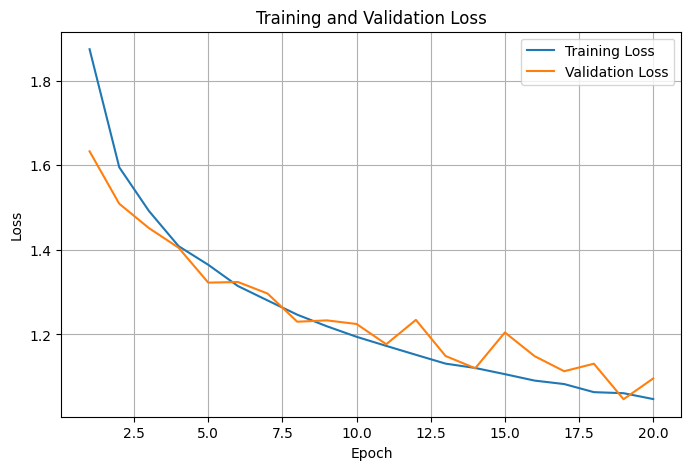

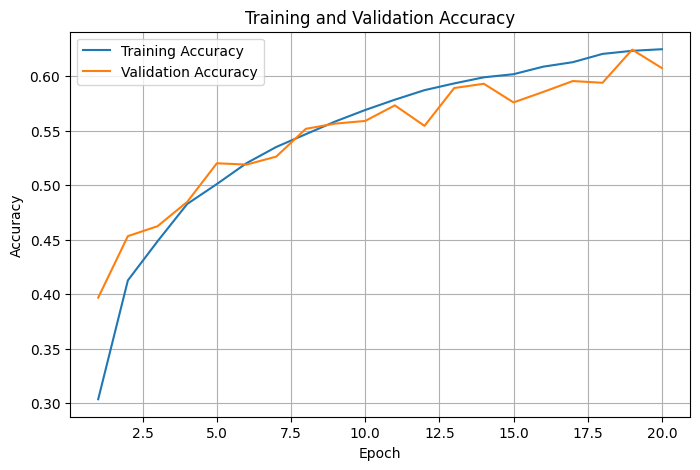

In [67]:
cnn_utils.plot_history(history_googlenet3_narrow)

In [68]:
test_loss, test_accuracy = cnn_utils.test_model(
    model=model,
    test_loader=test_loader,
    loss_function=loss_function,
    device=device
)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.2f}%")

Test Loss: 1.1159
Test Accuracy: 0.5972
Test Loss: 1.1159
Test Accuracy: 0.60%


## GoogLeNet3-Narrow Results

The GoogLeNet3-Narrow model was trained for 20 epochs using the fixed training configuration for the width experiment.

### Results

| Metric | Result |
|---|---:|
| Number of Inception Blocks | 3 |
| Output Channels per Block | 32 |
| Final Training Loss | 1.0473 |
| Final Training Accuracy | 62.46% |
| Final Validation Loss | 1.0961 |
| Final Validation Accuracy | 60.73% |
| Test Loss | 1.1159 |
| Test Accuracy | 59.72% |

### Training Behavior

The training loss decreased from 1.8743 at the beginning of training to 1.0473 by epoch 20.

Training accuracy increased from 30.37% to 62.46%, while validation accuracy increased from 39.68% to 60.73%.

The training and validation curves remained relatively close throughout training, with only a moderate difference between training and validation performance toward the end.

### Observation

The GoogLeNet3-Narrow model achieved a test accuracy of **59.72%** after 20 epochs.

This result provides the narrow-width reference point for the width experiment.

The model will be compared with the 64-channel Base and 96-channel Wide configurations to examine how increasing the width of the Inception blocks affects model performance and generalization.

## GoogLeNet3-Wide

### Objective

The GoogLeNet3-Wide model is the third configuration in the width experiment.

It uses **three Inception blocks**, while increasing the output width of each block from the 64-channel Base configuration to **96 channels**.

The purpose is to investigate whether increasing the width of the network further improves its ability to learn and generalize.

### Architecture

The model consists of:

```text
Input
3 × 32 × 32
      ↓
Inception Block 1
96 × 32 × 32
      ↓
MaxPool
96 × 16 × 16
      ↓
Inception Block 2
96 × 16 × 16
      ↓
MaxPool
96 × 8 × 8
      ↓
Inception Block 3
96 × 8 × 8
      ↓
Adaptive Average Pooling
96 × 1 × 1
      ↓
Linear Layer
10 classes

In [69]:
model = GoogLeNet(
    num_blocks=3,
    width=96
)

print(model)

GoogLeNet(
  (blocks): ModuleList(
    (0): InceptionBlock(
      (branch1): Sequential(
        (0): Conv2d(3, 24, kernel_size=(1, 1), stride=(1, 1))
        (1): ReLU()
      )
      (branch2): Sequential(
        (0): Conv2d(3, 24, kernel_size=(1, 1), stride=(1, 1))
        (1): ReLU()
        (2): Conv2d(24, 48, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (3): ReLU()
      )
      (branch3): Sequential(
        (0): Conv2d(3, 12, kernel_size=(1, 1), stride=(1, 1))
        (1): ReLU()
        (2): Conv2d(12, 12, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
        (3): ReLU()
      )
      (branch4): Sequential(
        (0): MaxPool2d(kernel_size=3, stride=1, padding=1, dilation=1, ceil_mode=False)
        (1): Conv2d(3, 12, kernel_size=(1, 1), stride=(1, 1))
        (2): ReLU()
      )
    )
    (1-2): 2 x InceptionBlock(
      (branch1): Sequential(
        (0): Conv2d(96, 24, kernel_size=(1, 1), stride=(1, 1))
        (1): ReLU()
      )
      (branch2): Sequ

In [70]:
images, labels = next(iter(train_loader))

output = model(images)

print(f"Input shape:  {images.shape}")
print(f"Output shape: {output.shape}")

Input shape:  torch.Size([64, 3, 32, 32])
Output shape: torch.Size([64, 10])


In [71]:
loss_function = nn.CrossEntropyLoss()

optimizer = optim.SGD(
    model.parameters(),
    lr=0.01,
    momentum=0.9
)

In [72]:
model, history_googlenet3_wide = cnn_utils.train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    loss_function=loss_function,
    optimizer=optimizer,
    device=device,
    epochs=20
)

Epoch [1/20] Train Loss: 1.7755 | Train Acc: 0.3427 | Val Loss: 1.5344 | Val Acc: 0.4410
Epoch [2/20] Train Loss: 1.4505 | Train Acc: 0.4696 | Val Loss: 1.3522 | Val Acc: 0.5070
Epoch [3/20] Train Loss: 1.3156 | Train Acc: 0.5241 | Val Loss: 1.2830 | Val Acc: 0.5227
Epoch [4/20] Train Loss: 1.2194 | Train Acc: 0.5622 | Val Loss: 1.2276 | Val Acc: 0.5523
Epoch [5/20] Train Loss: 1.1415 | Train Acc: 0.5894 | Val Loss: 1.1056 | Val Acc: 0.6095
Epoch [6/20] Train Loss: 1.0748 | Train Acc: 0.6154 | Val Loss: 1.0438 | Val Acc: 0.6269
Epoch [7/20] Train Loss: 1.0270 | Train Acc: 0.6336 | Val Loss: 1.0354 | Val Acc: 0.6354
Epoch [8/20] Train Loss: 0.9797 | Train Acc: 0.6499 | Val Loss: 0.9493 | Val Acc: 0.6627
Epoch [9/20] Train Loss: 0.9418 | Train Acc: 0.6686 | Val Loss: 0.9291 | Val Acc: 0.6716
Epoch [10/20] Train Loss: 0.9084 | Train Acc: 0.6776 | Val Loss: 0.9024 | Val Acc: 0.6791
Epoch [11/20] Train Loss: 0.8773 | Train Acc: 0.6894 | Val Loss: 0.9555 | Val Acc: 0.6655
Epoch [12/20] Train

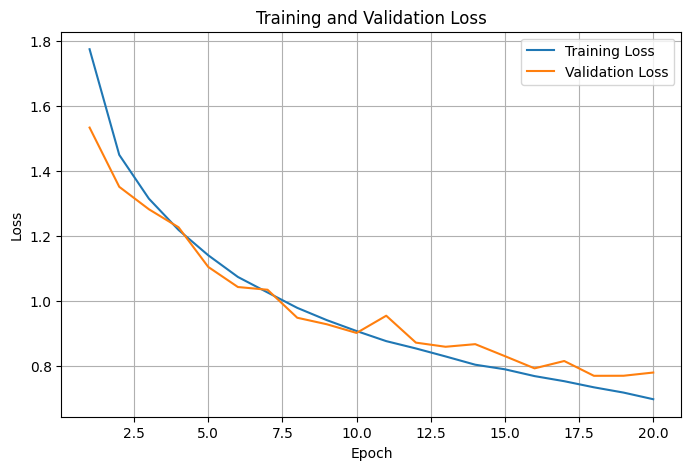

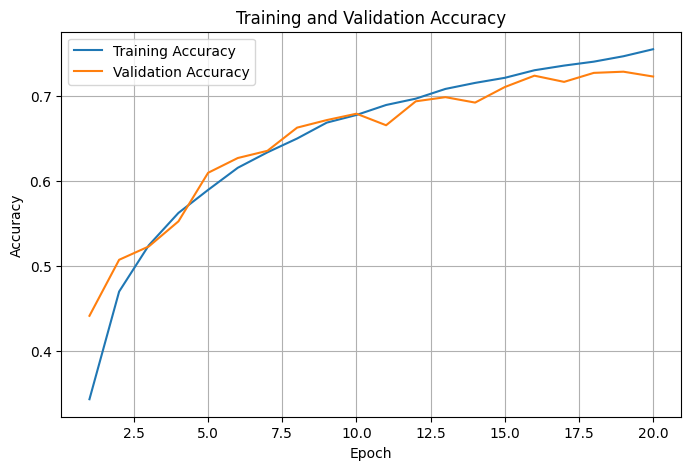

In [73]:
cnn_utils.plot_history(history_googlenet3_wide)

In [74]:
test_loss, test_accuracy = cnn_utils.test_model(
    model=model,
    test_loader=test_loader,
    loss_function=loss_function,
    device=device
)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.2f}%")

Test Loss: 0.7931
Test Accuracy: 0.7210
Test Loss: 0.7931
Test Accuracy: 0.72%


## GoogLeNet3-Wide Results

The GoogLeNet3-Wide model was trained for 20 epochs using the fixed training configuration for the width experiment.

### Results

| Metric | Result |
|---|---:|
| Number of Inception Blocks | 3 |
| Output Channels per Block | 96 |
| Final Training Loss | 0.6986 |
| Final Training Accuracy | 75.51% |
| Final Validation Loss | 0.7807 |
| Final Validation Accuracy | 72.29% |
| Test Loss | 0.7931 |
| Test Accuracy | 72.10% |

### Training Behavior

The training loss decreased from 1.7755 at the beginning of training to 0.6986 by epoch 20.

Training accuracy increased from 34.27% to 75.51%, while validation accuracy increased from 44.10% to 72.29%.

The training and validation curves followed a similar pattern throughout training. Toward the later epochs, training accuracy remained above validation accuracy, while validation loss remained slightly higher than training loss.

### Observation

The GoogLeNet3-Wide model achieved a test accuracy of **72.10%** after 20 epochs.

The three width configurations can now be compared:

| Model | Blocks | Width per Block | Test Accuracy |
|---|---:|---:|---:|
| GoogLeNet3-Narrow | 3 | 32 | 59.72% |
| GoogLeNet3-Base | 3 | 64 | 69.28% |
| GoogLeNet3-Wide | 3 | 96 | 72.10% |

Under the conditions of this experiment, increasing the width from 32 to 64 channels produced a substantial improvement in test accuracy. Increasing the width from 64 to 96 channels produced a further improvement.

The results will be used to analyze how increasing channel capacity affects the performance and generalization of the GoogLeNet architecture.

# Experiment 3 — Effect of Branch Structure

## Objective

The purpose of this experiment is to investigate how the number and type of parallel branches in an Inception block affect the performance of the GoogLeNet architecture.

Unlike the previous experiments, the main architectural variable in this experiment is the **branch structure**.

The number of Inception blocks will remain fixed at three, and the total output width of each block will remain approximately constant at 64 channels.

This allows us to study the effect of using different numbers of parallel feature-extraction paths.

---

## Experimental Design

All three models will contain exactly **three Inception blocks**.

The total output width of each block will be kept at **64 channels**.

The branch structure will change as follows:

| Model | Number of Branches | Branch Allocation | Total Output Channels |
|---|---:|---|---:|
| GoogLeNet3-2Branch | 2 | 32 + 32 | 64 |
| GoogLeNet3-3Branch | 3 | 16 + 32 + 16 | 64 |
| GoogLeNet3-4Branch | 4 | 16 + 32 + 8 + 8 | 64 |

---

## 2-Branch Model

The 2-branch model will use:

```text
Branch 1: 1 × 1 → 32 channels

Branch 2: 1 × 1 → 3 × 3 → 32 channels

In [75]:
class InceptionBlock(nn.Module):

    def __init__(self, in_channels, num_branches):
        super().__init__()

        self.num_branches = num_branches

        if num_branches == 2:

            self.branch1 = nn.Sequential(
                nn.Conv2d(in_channels, 32, kernel_size=1),
                nn.ReLU()
            )

            self.branch2 = nn.Sequential(
                nn.Conv2d(in_channels, 16, kernel_size=1),
                nn.ReLU(),

                nn.Conv2d(16, 32, kernel_size=3, padding=1),
                nn.ReLU()
            )

        elif num_branches == 3:

            self.branch1 = nn.Sequential(
                nn.Conv2d(in_channels, 16, kernel_size=1),
                nn.ReLU()
            )

            self.branch2 = nn.Sequential(
                nn.Conv2d(in_channels, 16, kernel_size=1),
                nn.ReLU(),

                nn.Conv2d(16, 32, kernel_size=3, padding=1),
                nn.ReLU()
            )

            self.branch3 = nn.Sequential(
                nn.Conv2d(in_channels, 8, kernel_size=1),
                nn.ReLU(),

                nn.Conv2d(8, 16, kernel_size=5, padding=2),
                nn.ReLU()
            )

        elif num_branches == 4:

            self.branch1 = nn.Sequential(
                nn.Conv2d(in_channels, 16, kernel_size=1),
                nn.ReLU()
            )

            self.branch2 = nn.Sequential(
                nn.Conv2d(in_channels, 16, kernel_size=1),
                nn.ReLU(),

                nn.Conv2d(16, 32, kernel_size=3, padding=1),
                nn.ReLU()
            )

            self.branch3 = nn.Sequential(
                nn.Conv2d(in_channels, 8, kernel_size=1),
                nn.ReLU(),

                nn.Conv2d(8, 8, kernel_size=5, padding=2),
                nn.ReLU()
            )

            self.branch4 = nn.Sequential(
                nn.MaxPool2d(
                    kernel_size=3,
                    stride=1,
                    padding=1
                ),

                nn.Conv2d(in_channels, 8, kernel_size=1),
                nn.ReLU()
            )

        else:
            raise ValueError("num_branches must be 2, 3, or 4")

        self._initialize_weights()

    def _initialize_weights(self):

        for layer in self.modules():

            if isinstance(layer, nn.Conv2d):

                nn.init.kaiming_normal_(
                    layer.weight,
                    mode="fan_out",
                    nonlinearity="relu"
                )

                if layer.bias is not None:
                    nn.init.zeros_(layer.bias)

    def forward(self, x):

        outputs = [
            self.branch1(x),
            self.branch2(x)
        ]

        if self.num_branches >= 3:
            outputs.append(self.branch3(x))

        if self.num_branches == 4:
            outputs.append(self.branch4(x))

        return torch.cat(outputs, dim=1)

In [76]:
class GoogLeNetBranch(nn.Module):

    def __init__(self, num_branches):
        super().__init__()

        self.blocks = nn.ModuleList([
            InceptionBlock(
                in_channels=3,
                num_branches=num_branches
            ),

            InceptionBlock(
                in_channels=64,
                num_branches=num_branches
            ),

            InceptionBlock(
                in_channels=64,
                num_branches=num_branches
            )
        ])

        self.pool = nn.MaxPool2d(
            kernel_size=2,
            stride=2
        )

        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d((1, 1)),
            nn.Flatten(),
            nn.Linear(64, 10)
        )

        self._initialize_classifier()

    def _initialize_classifier(self):

        nn.init.xavier_normal_(
            self.classifier[2].weight
        )

        nn.init.zeros_(
            self.classifier[2].bias
        )

    def forward(self, x):

        x = self.blocks[0](x)
        x = self.pool(x)

        x = self.blocks[1](x)
        x = self.pool(x)

        x = self.blocks[2](x)

        x = self.classifier(x)

        return x

## Sub-experiment 1 — GoogLeNet3-2Branch

### Objective

The first model in the branch-structure experiment uses **two parallel branches** inside each Inception block.

The purpose is to establish how a reduced branch structure performs before adding more parallel feature-extraction paths.

The number of Inception blocks and the total output width will remain fixed.

### Architecture

The model contains:

- 3 Inception blocks
- 64 output channels per block
- 2 branches in each Inception block

The two branches are:

```text
Branch 1: 1 × 1 → 32 channels

Branch 2: 1 × 1 → 3 × 3 → 32 channels

In [77]:
model = GoogLeNetBranch(num_branches=2)

In [78]:
images, labels = next(iter(train_loader))

output = model(images)

print(f"Input shape:  {images.shape}")
print(f"Output shape: {output.shape}")

Input shape:  torch.Size([64, 3, 32, 32])
Output shape: torch.Size([64, 10])


In [80]:
loss_function = nn.CrossEntropyLoss()

optimizer = optim.SGD(
    model.parameters(),
    lr=0.01,
    momentum=0.9
)

In [81]:
model, history_googlenet_2branch = cnn_utils.train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    loss_function=loss_function,
    optimizer=optimizer,
    device=device,
    epochs=20
)

Epoch [1/20] Train Loss: 1.8485 | Train Acc: 0.3004 | Val Loss: 1.6903 | Val Acc: 0.3566
Epoch [2/20] Train Loss: 1.5729 | Train Acc: 0.4116 | Val Loss: 1.5187 | Val Acc: 0.4318
Epoch [3/20] Train Loss: 1.4368 | Train Acc: 0.4722 | Val Loss: 1.3909 | Val Acc: 0.4880
Epoch [4/20] Train Loss: 1.3338 | Train Acc: 0.5182 | Val Loss: 1.3206 | Val Acc: 0.5168
Epoch [5/20] Train Loss: 1.2546 | Train Acc: 0.5455 | Val Loss: 1.2634 | Val Acc: 0.5369
Epoch [6/20] Train Loss: 1.1898 | Train Acc: 0.5726 | Val Loss: 1.2020 | Val Acc: 0.5637
Epoch [7/20] Train Loss: 1.1368 | Train Acc: 0.5947 | Val Loss: 1.1356 | Val Acc: 0.5901
Epoch [8/20] Train Loss: 1.1102 | Train Acc: 0.6028 | Val Loss: 1.1192 | Val Acc: 0.6017
Epoch [9/20] Train Loss: 1.0534 | Train Acc: 0.6244 | Val Loss: 1.0564 | Val Acc: 0.6290
Epoch [10/20] Train Loss: 1.0214 | Train Acc: 0.6383 | Val Loss: 1.0326 | Val Acc: 0.6339
Epoch [11/20] Train Loss: 0.9917 | Train Acc: 0.6488 | Val Loss: 0.9696 | Val Acc: 0.6542
Epoch [12/20] Train

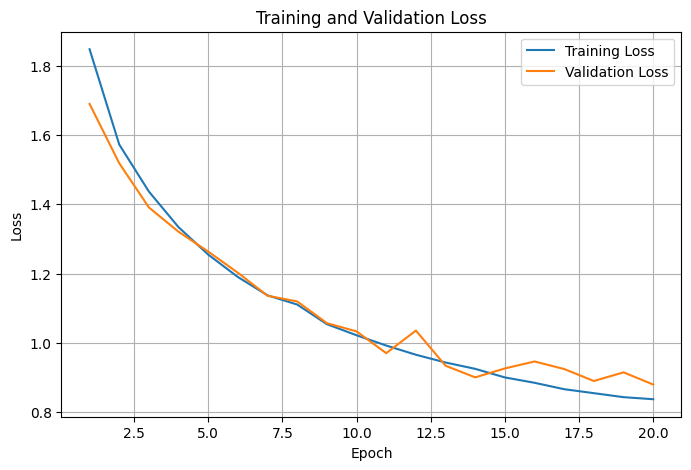

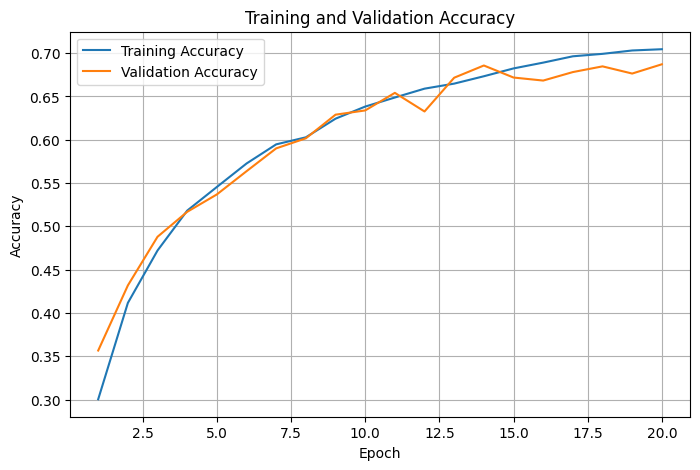

In [82]:
cnn_utils.plot_history(history_googlenet_2branch)

In [83]:
test_loss, test_accuracy = cnn_utils.test_model(
    model=model,
    test_loader=test_loader,
    loss_function=loss_function,
    device=device
)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.2f}%")

Test Loss: 0.8913
Test Accuracy: 0.6868
Test Loss: 0.8913
Test Accuracy: 0.69%


## GoogLeNet3-2Branch Results

The GoogLeNet3-2Branch model was trained for 20 epochs using the fixed training configuration for the branch-structure experiment.

### Results

| Metric | Result |
|---|---:|
| Number of Inception Blocks | 3 |
| Number of Branches | 2 |
| Output Channels per Block | 64 |
| Final Training Loss | 0.8365 |
| Final Training Accuracy | 70.46% |
| Final Validation Loss | 0.8790 |
| Final Validation Accuracy | 68.72% |
| Test Loss | 0.8913 |
| Test Accuracy | 68.68% |

### Training Behavior

The training loss decreased from 1.8485 at the beginning of training to 0.8365 by epoch 20.

Training accuracy increased from 30.04% to 70.46%, while validation accuracy increased from 35.66% to 68.72%.

The training and validation curves remained relatively close throughout training. By the later epochs, training accuracy was slightly higher than validation accuracy, while validation loss remained slightly higher than training loss.

### Observation

The GoogLeNet3-2Branch model achieved a test accuracy of **68.68%** after 20 epochs.

This provides the first reference point for the branch-structure experiment.

The result will be compared with the 3-branch and 4-branch configurations while keeping the number of Inception blocks and total output width fixed.

The branch-structure comparison will therefore examine:

```text
2 branches → 3 branches → 4 branches

## Sub-experiment 2 — GoogLeNet3-3Branch

### Objective

The second model in the branch-structure experiment uses **three parallel branches** inside each Inception block.

The purpose is to investigate whether adding a third feature-extraction path improves performance compared with the 2-branch configuration.

The number of Inception blocks and the total output width will remain fixed.

### Architecture

The model contains:

- 3 Inception blocks
- 64 output channels per block
- 3 branches in each Inception block

The three branches are:

```text
Branch 1: 1 × 1 → 16 channels

Branch 2: 1 × 1 → 3 × 3 → 32 channels

Branch 3: 1 × 1 → 5 × 5 → 16 channels

In [84]:
model = GoogLeNetBranch(num_branches=3)

print(model)

GoogLeNetBranch(
  (blocks): ModuleList(
    (0): InceptionBlock(
      (branch1): Sequential(
        (0): Conv2d(3, 16, kernel_size=(1, 1), stride=(1, 1))
        (1): ReLU()
      )
      (branch2): Sequential(
        (0): Conv2d(3, 16, kernel_size=(1, 1), stride=(1, 1))
        (1): ReLU()
        (2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (3): ReLU()
      )
      (branch3): Sequential(
        (0): Conv2d(3, 8, kernel_size=(1, 1), stride=(1, 1))
        (1): ReLU()
        (2): Conv2d(8, 16, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
        (3): ReLU()
      )
    )
    (1-2): 2 x InceptionBlock(
      (branch1): Sequential(
        (0): Conv2d(64, 16, kernel_size=(1, 1), stride=(1, 1))
        (1): ReLU()
      )
      (branch2): Sequential(
        (0): Conv2d(64, 16, kernel_size=(1, 1), stride=(1, 1))
        (1): ReLU()
        (2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (3): ReLU()
      )
     

In [85]:
images, labels = next(iter(train_loader))

output = model(images)

print(f"Input shape:  {images.shape}")
print(f"Output shape: {output.shape}")

Input shape: torch.Size([64, 3, 32, 32])
Output shape: torch.Size([64, 10])


In [86]:
loss_function = nn.CrossEntropyLoss()

optimizer = optim.SGD(
    model.parameters(),
    lr=0.01,
    momentum=0.9
)

In [87]:
model, history_googlenet_3branch = cnn_utils.train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    loss_function=loss_function,
    optimizer=optimizer,
    device=device,
    epochs=20
)

Epoch [1/20] Train Loss: 1.7791 | Train Acc: 0.3286 | Val Loss: 1.5561 | Val Acc: 0.4105
Epoch [2/20] Train Loss: 1.4615 | Train Acc: 0.4652 | Val Loss: 1.3705 | Val Acc: 0.5061
Epoch [3/20] Train Loss: 1.3169 | Train Acc: 0.5259 | Val Loss: 1.2079 | Val Acc: 0.5618
Epoch [4/20] Train Loss: 1.1889 | Train Acc: 0.5769 | Val Loss: 1.1099 | Val Acc: 0.6076
Epoch [5/20] Train Loss: 1.1240 | Train Acc: 0.6003 | Val Loss: 1.1259 | Val Acc: 0.6063
Epoch [6/20] Train Loss: 1.0644 | Train Acc: 0.6222 | Val Loss: 1.0030 | Val Acc: 0.6455
Epoch [7/20] Train Loss: 1.0171 | Train Acc: 0.6402 | Val Loss: 1.0525 | Val Acc: 0.6164
Epoch [8/20] Train Loss: 0.9778 | Train Acc: 0.6542 | Val Loss: 0.9639 | Val Acc: 0.6653
Epoch [9/20] Train Loss: 0.9510 | Train Acc: 0.6640 | Val Loss: 0.9418 | Val Acc: 0.6639
Epoch [10/20] Train Loss: 0.9164 | Train Acc: 0.6751 | Val Loss: 0.9244 | Val Acc: 0.6731
Epoch [11/20] Train Loss: 0.8872 | Train Acc: 0.6872 | Val Loss: 0.8761 | Val Acc: 0.6864
Epoch [12/20] Train

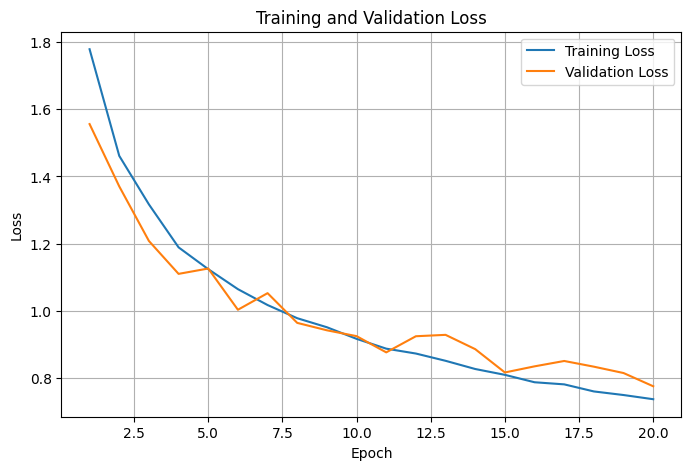

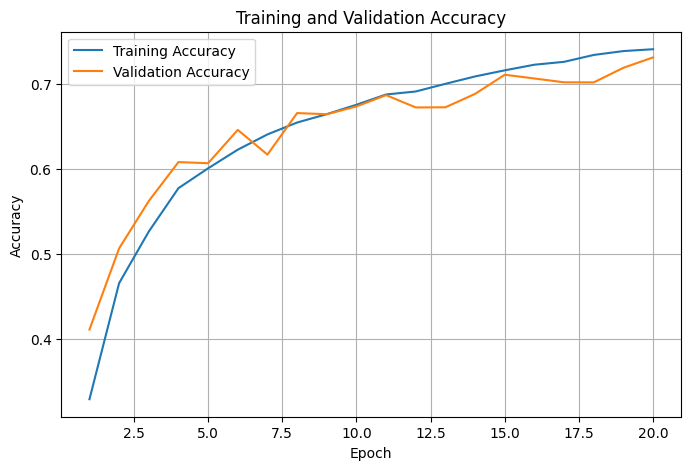

In [88]:
cnn_utils.plot_history(history_googlenet_3branch)

In [89]:
test_loss, test_accuracy = cnn_utils.test_model(
    model=model,
    test_loader=test_loader,
    loss_function=loss_function,
    device=device
)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.2f}%")

Test Loss: 0.8002
Test Accuracy: 0.7223
Test Loss: 0.8002
Test Accuracy: 0.72%


## GoogLeNet3-3Branch Results

The GoogLeNet3-3Branch model was trained for 20 epochs using the fixed training configuration for the branch-structure experiment.

### Results

| Metric | Result |
|---|---:|
| Number of Inception Blocks | 3 |
| Number of Branches | 3 |
| Output Channels per Block | 64 |
| Final Training Loss | 0.7365 |
| Final Training Accuracy | 74.04% |
| Final Validation Loss | 0.7751 |
| Final Validation Accuracy | 73.08% |
| Test Loss | 0.8002 |
| Test Accuracy | 72.23% |

### Training Behavior

The training loss decreased from 1.7791 at the beginning of training to 0.7365 by epoch 20.

Training accuracy increased from 32.86% to 74.04%, while validation accuracy increased from 41.05% to 73.08%.

The training and validation curves remained relatively close throughout most of the training process. By the end of training, the difference between training and validation accuracy was small.

### Observation

The GoogLeNet3-3Branch model achieved a test accuracy of **72.23%** after 20 epochs.

Compared with the 2-branch configuration, test accuracy increased from **68.68% to 72.23%**.

The final comparison will include the 4-branch configuration while keeping the number of Inception blocks and total output width fixed.

The branch-structure comparison is therefore:

```text
2 branches → 3 branches → 4 branches

# GoogLeNet / Inception Architecture Study — Overall Results

The GoogLeNet experiments were designed to investigate how different architectural choices affect CNN classification performance on CIFAR-10.

Three architectural factors were studied:

1. Depth
2. Width
3. Branch structure

The training configuration was kept fixed across experiments so that the architectural changes could be examined under controlled conditions.

---

# Experiment 1 — Effect of Depth

The first experiment investigated the effect of increasing the number of Inception blocks.

The width and branch structure were kept fixed:

- 64 output channels per block
- 4 Inception branches
- Same branch allocation: `16 + 32 + 8 + 8`

### Results

| Model | Inception Blocks | Width | Test Accuracy |
|---|---:|---:|---:|
| GoogLeNet2 | 2 | 64 | 61.53% |
| GoogLeNet3 | 3 | 64 | 69.28% |
| GoogLeNet4 | 4 | 64 | 68.48% |

### Observation

Increasing the depth from 2 to 3 Inception blocks produced a substantial improvement in test accuracy.

However, increasing the depth from 3 to 4 blocks did not produce a further improvement under the experimental conditions.

The 3-block model therefore provided the highest test accuracy within this depth experiment.

---

# Experiment 2 — Effect of Width

The second experiment investigated the effect of increasing the number of output channels in the Inception blocks.

The number of blocks was fixed at three, while the width was changed.

### Results

| Model | Inception Blocks | Width per Block | Test Accuracy |
|---|---:|---:|---:|
| GoogLeNet3-Narrow | 3 | 32 | 59.72% |
| GoogLeNet3-Base | 3 | 64 | 69.28% |
| GoogLeNet3-Wide | 3 | 96 | 72.10% |

### Observation

Increasing the width from 32 to 64 channels produced a substantial improvement in test accuracy.

Increasing the width from 64 to 96 channels produced a further improvement.

Under these experimental conditions, increasing the number of channels increased the model's classification performance across the tested configurations.

---

# Experiment 3 — Effect of Branch Structure

The third experiment investigated the effect of changing the number of parallel branches inside the Inception blocks.

The number of Inception blocks was fixed at three, and the total output width was fixed at 64 channels per block.

### Results

| Model | Branches | Blocks | Width | Test Accuracy |
|---|---:|---:|---:|---:|
| GoogLeNet3-2Branch | 2 | 3 | 64 | 68.68% |
| GoogLeNet3-3Branch | 3 | 3 | 64 | 72.23% |
| GoogLeNet3-4Branch | 4 | 3 | 64 | 69.28% |

The 4-branch result comes from the previously trained GoogLeNet3-Base model because it used the same 3-block, 64-channel, 4-branch architecture and the same training configuration.

### Observation

Increasing the number of branches from two to three improved test accuracy from 68.68% to 72.23%.

The four-branch configuration achieved 69.28%, which was lower than the three-branch configuration under these experimental conditions.

This suggests that adding more branches did not automatically produce better performance. The specific combination of branches and their channel allocation affected the result.

---

# Overall GoogLeNet Findings

The three experiments examined different aspects of the GoogLeNet architecture while controlling the other major architectural variables.

### Depth

```text
2 blocks → 61.53%
3 blocks → 69.28%
4 blocks → 68.48%

```

### Width

```text
32 channels → 59.72%
64 channels → 69.28%
96 channels → 72.10%
```

### Branch Structure

```text
2 branches → 68.68%
3 branches → 72.23%
4 branches → 69.28%
```
# Conclusion

The experiments show that GoogLeNet performance was affected by depth, width, and branch structure.

Increasing depth improved performance up to the 3-block configuration, while increasing width from 32 to 96 channels produced progressively higher test accuracy.

Changing the branch structure also affected performance. The 3-branch configuration achieved 72.23% test accuracy, while both the 2-branch and 4-branch configurations produced lower test accuracy under the same experimental conditions.

These results demonstrate that CNN architecture is not determined by a single factor. Depth, width, and the way feature-extraction paths are organized can interact to produce different learning and generalization behavior.